In [3]:
import h5py
import numpy as np
import pynbody

import numpy as np
from pynbody.array import SimArray as SimArray
simpath = '/data/REPOSITORY/FIRE/m10q_res30/output/snapdir_600/snapshot_600'
s = pynbody.load(simpath)
s.set_units_system(distance=pynbody.units.Unit('1.0 kpc a h^-1'),  # length
    mass=pynbody.units.Unit('1.0e10 Msol h^-1'),  # mass
    velocity=pynbody.units.Unit('1.0 km s^-1')  # velocity
                    )
s.physical_units()
halopath = '/data/bk639/FIRE2/m10q/snapdir_600/halo_600.hdf5'



In [2]:
h = s.halos()

RuntimeError: No halo catalogue found for '<GadgetHDFSnap "/data/bk639/FIRE2/mhd/m10v_res250/output/snapdir_600/snapshot_600" len=87030537>'

In [3]:
print(s['mass'].units,s['pos'].units,s['vel'].units)

print(s['pos'].units,s['pos'].units,s['vel'].units)



/home/bk639/miniconda3/envs/pynbody_beta/lib/python3.12/site-packages/pynbody/snapshot/gadgethdf.py:472: UserWarning: Unable to infer units from HDF attributes
  warnings.warn("Unable to infer units from HDF attributes")


Msol kpc km s**-1
kpc kpc km s**-1


In [14]:
import configparser
print(pynbody.configuration.config_parser.get('gadget-units', 'pos'))

Mpc a h^-1


In [28]:
print(s.properties['h'])
print(s.properties['a'])

0.702
1.0


In [34]:

print(np.median(s.dm['mass'].in_units('Msol')))
print(np.average(s.s['mass'].in_units('Msol')))
print(np.average(s.gas['mass'].in_units('Msol')))

/home/bk639/miniconda3/envs/pynbody_beta/lib/python3.12/site-packages/pynbody/snapshot/gadgethdf.py:472: UserWarning: Unable to infer units from HDF attributes
  warnings.warn("Unable to infer units from HDF attributes")


1303.0021759252975
179.10469158335218
261.8296423354905


In [12]:
s.s[0:100]['V_lum_den']


ValueError: operands could not be broadcast together with shapes (213444,15) (213444,) 

In [3]:



class RockstarHDF5Catalog:
    def __init__(self, hdf5_file):
        with h5py.File(hdf5_file, 'r') as f:
            # Read properties
            self.id = f['id'][:]
            self.mass = f['mass'][:] # Msun/h
            self.position = f['position'][:]  # kpc (physical)
            self.velocity = f['velocity'][:]  # km/s (physical)
            self.radius = f['radius'][:]  # kpc (physical)
            self.vel_circ_max = f['vel.circ.max'][:]  # km/s

            # Read various mass definitions
            self.mass_200c = f['mass.200c'][:]
            self.mass_vir = f['mass.vir'][:]

            # Cosmology
            self.h = f['cosmology:hubble'][()]
            self.box_length_kpc = f['info:box.length'][()]  # kpc (physical)

            #convert to SimArray
            self.mass = SimArray(self.mass, units='Msol')
            self.mass_200c = SimArray(self.mass_200c, units='Msol')
            self.mass_vir = SimArray(self.mass_vir, units='Msol')
            self.position = SimArray(self.position, units='kpc')
            self.velocity = SimArray(self.velocity, units='km s^-1')
            self.radius = SimArray(self.radius, units='kpc')


    def __len__(self):
        return len(self.id)

    def get_position_Mpc(self, index):
        """Get position in Mpc (physical)"""
        return self.position[index] / 1000.0


    def select_sphere(self, sim, halo_index, radius_kpc=None,
                                   radius_factor=1.0):
        """
        Select particles within a sphere around a halo.

        Parameters:
        -----------
        sim : pynbody snapshot (assumes positions in Mpc/h comoving)
        halo_index : index of halo
        radius_kpc : radius in kpc (physical). If None, uses halo radius
        radius_factor : multiply halo radius by this factor (if radius_kpc not given)
        """
        # Get halo center in kpc (physical)
        center_kpc = self.position[halo_index]
        # Get radius
        if radius_kpc is None:
            radius_kpc = self.radius[halo_index] * radius_factor
        print(f"Selecting particles within {radius_kpc:.2f} kpc of halo {halo_index} at {center_kpc} kpc")
        # Center and select
        sphere_filter = pynbody.filt.Sphere(radius_kpc, center_kpc)

        return sim[sphere_filter]

# Load catalog
halos = RockstarHDF5Catalog(halopath)

print(f"Number of halos: {len(halos)}")
print(f"h = {halos.h:.3f}")
print(f"Box size: {halos.box_length_kpc:.1f} kpc = {halos.box_length_kpc/1000:.3f} Mpc")

# Most massive halo
idx = np.argmax(halos.mass)
print(f"\nMost massive halo (index {idx}):")
print(f"  ID: {halos.id[idx]}")
print(f"  Mass: {halos.mass[idx]:.2e} Msun")
print(f"  Position: {halos.position[idx]} kpc (physical)")
print(f"  Radius: {halos.radius[idx]:.2f} kpc (physical)")
print(f"  Vmax: {halos.vel_circ_max[idx]:.1f} km/s")


Number of halos: 12819
h = 0.702
Box size: 7122.5 kpc = 7.123 Mpc

Most massive halo (index 5837):
  ID: 12805
  Mass: 7.89e+09 Msun
  Position: [3348.6753 2926.5386 3317.2224] kpc (physical)
  Radius: 63.22 kpc (physical)
  Vmax: 33.6 km/s


In [17]:
print(f'Particles in simulation: {len(s):.2e}')

Particles in simulation: 8.70e+07


In [13]:
halo_particles = halos.select_sphere(s, idx, radius_factor=1/100)
print(f"\nParticles in sphere around most massive halo: {len(halo_particles)}")

/home/bk639/miniconda3/envs/pynbody_beta/lib/python3.12/site-packages/pynbody/snapshot/gadgethdf.py:472: UserWarning: Unable to infer units from HDF attributes
  warnings.warn("Unable to infer units from HDF attributes")


KeyboardInterrupt: 

In [5]:
with h5py.File('/data/bk639/FIRE2/m10q/snapdir_600/snapshot_600.0.hdf5', 'r') as f:
    print("Keys in HDF5 file:")
    def print_structure(name):
        print(name)
    f.visit(print_structure)

Keys in HDF5 file:
Header
PartType0
PartType0/Coordinates
PartType0/Density
PartType0/ElectronAbundance
PartType0/InternalEnergy
PartType0/Masses
PartType0/Metallicity
PartType0/NeutralHydrogenAbundance
PartType0/ParticleChildIDsNumber
PartType0/ParticleIDGenerationNumber
PartType0/ParticleIDs
PartType0/SmoothingLength
PartType0/StarFormationRate
PartType0/Velocities
PartType1
PartType1/Coordinates
PartType1/Masses
PartType1/ParticleChildIDsNumber
PartType1/ParticleIDGenerationNumber
PartType1/ParticleIDs
PartType1/Velocities
PartType2
PartType2/Coordinates
PartType2/Masses
PartType2/ParticleChildIDsNumber
PartType2/ParticleIDGenerationNumber
PartType2/ParticleIDs
PartType2/Velocities
PartType4
PartType4/Coordinates
PartType4/Masses
PartType4/Metallicity
PartType4/OStarNumber
PartType4/ParticleChildIDsNumber
PartType4/ParticleIDGenerationNumber
PartType4/ParticleIDs
PartType4/StellarFormationTime
PartType4/Velocities


In [6]:
with h5py.File('/data/bk639/FIRE2/m10q/snapdir_600/snapshot_600.0.hdf5', 'r') as f:
    header = f['Header']
    print("Header attributes:")
    for key in header.attrs.keys():
        print(f"  {key}: {header.attrs[key]}")

Header attributes:
  BoxSize: 5000.0
  CompactLevel: 0
  Compactify_Version: v0.1
  Flag_Cooling: 1
  Flag_DoublePrecision: 0
  Flag_Feedback: 1
  Flag_IC_Info: 3
  Flag_Metals: 15
  Flag_Sfr: 1
  Flag_StellarAge: 1
  HubbleParam: 0.702
  MassTable: [0. 0. 0. 0. 0. 0.]
  NumFilesPerSnapshot: 16
  NumPart_ThisFile: [7527462 8373169  565789       0   11485       0]
  NumPart_Total: [123955434 124215200   6410380         0    213444         0]
  NumPart_Total_HighWord: [0 0 0 0 0 0]
  Omega0: 0.272
  OmegaLambda: 0.728
  ReadMe: This is a snapshot of FIREbox (PI: Feldmann) -- FIREbox is part of the Feedback in Realistic Environments (FIRE) project -- Use, modification, or distribution only permitted with approval of the PI and the core FIRE team -- No warranty, use at your own risk -- We acknowledge PRACE for awarding us access to MareNostrum at BSC (Barcelona)
  Redshift: 3.0426969832575423e-09
  Time: 0.9999999969573031


In [14]:
import h5py
import numpy as np

with h5py.File(halopath, 'r') as f:
    # Get cosmology
    h = f['cosmology:hubble'][()]
    box_length = f['info:box.length'][()]
    box_length_over_h = f['info:box.length_div.by_h'][()]

    print(f"Hubble parameter h: {h}")
    print(f"Box length: {box_length}")
    print(f"Box length / h: {box_length_over_h}")
    print(f"Ratio: {box_length / box_length_over_h:.6f}")

    # Check position ranges
    positions = f['position'][:]
    print(f"\nPosition ranges:")
    print(f"  X: [{positions[:,0].min():.3f}, {positions[:,0].max():.3f}]")
    print(f"  Y: [{positions[:,1].min():.3f}, {positions[:,1].max():.3f}]")
    print(f"  Z: [{positions[:,2].min():.3f}, {positions[:,2].max():.3f}]")
    print(f"  Expected: [0, {box_length_over_h:.3f}] if in Mpc/h")

    # Check mass range
    mass = f['mass'][:]
    print(f"\nMass range: [{mass.min():.2e}, {mass.max():.2e}]")
    print(f"  Expected: O(10^4 - 10^12) if in Msun/h")

    # Check velocities
    velocity = f['velocity'][:]
    vel_mag = np.sqrt(np.sum(velocity**2, axis=1))
    print(f"\nVelocity magnitude range: [{vel_mag.min():.1f}, {vel_mag.max():.1f}]")
    print(f"  Expected: O(10 - 1000) if in km/s")

Hubble parameter h: 0.7020000000000001
Box length: 7122.507122507123
Box length / h: 5000.0
Ratio: 1.424501

Position ranges:
  X: [44.288, 7119.146]
  Y: [1223.761, 6278.988]
  Z: [541.168, 4134.672]
  Expected: [0, 5000.000] if in Mpc/h

Mass range: [3.11e+04, 7.89e+09]
  Expected: O(10^4 - 10^12) if in Msun/h

Velocity magnitude range: [0.3, 281.6]
  Expected: O(10 - 1000) if in km/s


In [13]:
pynbody.analysis.halo.center(s.s)

<Transformation null, translate, offset_velocity>

In [8]:
len(s)

38653282

In [2]:
r = SimArray((3348.6753, 2926.5386, 3317.2224), units='kpc')


# get a small list of particles around this position within ~50 kpc print indexes
d = s.dm[40000:50000]['pos'] - r
d = np.sqrt((d**2).sum(axis=1))
idx = np.where(d < 18)[0]
print(idx)
print(len(idx))
print(s.dm[idx]['pos'])

/home/bk639/miniconda3/envs/pynbody_beta/lib/python3.12/site-packages/pynbody/snapshot/gadgethdf.py:472: UserWarning: Unable to infer units from HDF attributes
  warnings.warn("Unable to infer units from HDF attributes")


[1088 1170 1171 1175 1176 1177 1178 1179 1180 1181 1182 1183 1184 1185
 1186 1187 1188 1189 1190 1191 1192 1193 1194 1195 1196 1197 1198 1199
 1200 1201 1202 1203 1204 1205 1206 1207 1208 1209 1210 1211 1212 1213
 1214 1215 1216 1217 1243 1244 1245 1246 1247 1248 1249 1250 1251 1252
 1253 1254 1255 1256 1257 1258 1259 1260 1263 1264 1265 1266 1267 1268
 1269 1270 1271 1272 1273 1274 1275 1276 1277 1278 1279 1281 1282 1283
 1284 1285 1286 1289 1290 1291 1310 1311 1321 1322 9546 9551 9557 9558
 9560 9561 9562 9563 9564 9754 9755 9756 9757 9758 9760 9762 9763 9764
 9765 9766 9767 9768 9769 9770 9771 9772 9773 9827 9828 9829 9830 9831
 9832 9843 9845 9846 9847 9848 9849 9850 9851 9852 9853 9854 9855 9856
 9857 9858 9859 9860 9861 9862 9863 9864 9865 9866 9867 9868 9869 9870
 9873 9874 9876 9932 9933 9934]
160
[[2760.65777477 3167.50752532 3432.90092159]
 [2761.36338924 3167.42943331 3433.08524342]
 [2761.30907532 3167.50713285 3433.19630903]
 [2761.34270352 3167.61753725 3433.17556808]
 [2

In [10]:
pynbody.analysis.halo.center(s.s)


KeyboardInterrupt: 

In [15]:
s['mass'].sum().in_units('Msol')

SimArray(1.34411265e+13, 'Msol')

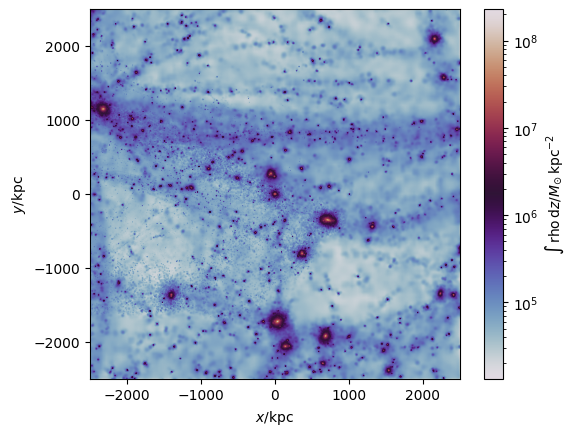

In [25]:

pynbody.plot.image(s.dm, width="5000 kpc", units="Msol kpc^-2", cmap="twilight")


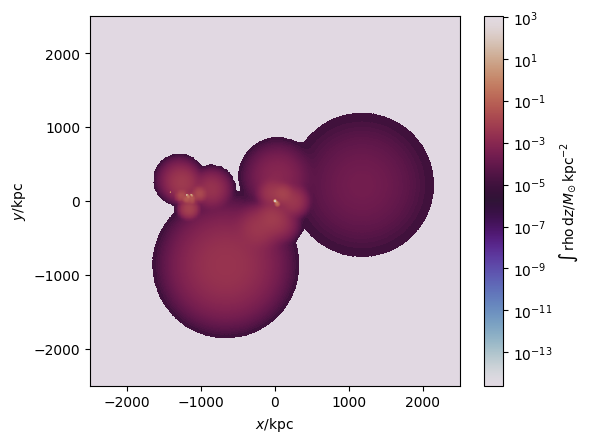

In [24]:
pynbody.plot.image(s.s, width="5000 kpc", units="Msol kpc^-2", cmap="twilight")


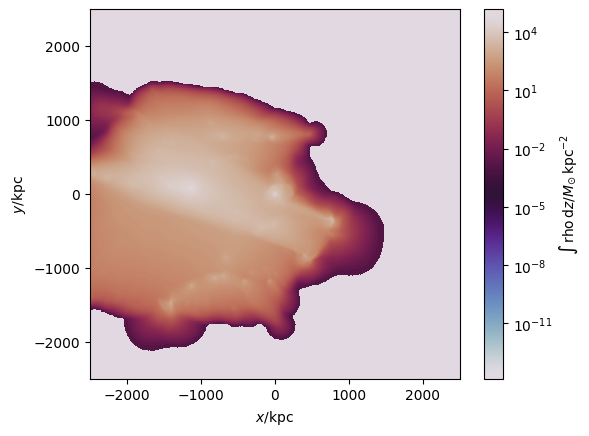

In [26]:
pynbody.plot.image(s.g, width="5000 kpc", units="Msol kpc^-2", cmap="twilight")


SimArray([[-5.51874957e+02,  2.33583365e+02,  9.01721324e+01],
          [-5.50809185e+02,  2.33549744e+02,  9.02531424e+01],
          [-2.07169691e-01, -1.24853145e-01,  6.45031139e-01],
          ...,
          [ 1.08812701e-01,  4.37227235e-01,  1.44926293e+00],
          [ 6.49152756e-02,  5.39620408e-01,  1.36580340e+00],
          [-3.55276518e-01,  3.84390139e+00,  1.17653288e+00]],
         shape=(14959, 3), 'kpc')

In [22]:
from __future__ import annotations

import glob
import os.path
import sys

import numpy as np
from pynbody import util

from pynbody.halo import HaloCatalogue
from .details import number_mapping
class MyHaloCatalogue(HaloCatalogue):
    def __init__(self, sim, filename=None, format_revision=None):
        """Initialize a RockstarCatalogue.

        Parameters
        ----------

        sim : :class:`pynbody.snapshot.simsnap.SimSnap`
            The simulation snapshot to which this catalogue applies.

        filename : str, optional
            The path to the Rockstar outputs. This can either be the first binary file in the series (e.g.
            ``path/to/halos_15.0.bin``) or the stem for the series (e.g. ``path/to/halos_15``). If not specified,
            the code will attempt to find the Rockstar outputs in the same directory as the simulation snapshot.

        format_revision : int, str, optional
            Override the header's format revision information. Specify 1, 2, 'caterpillar', 'galaxies' for Rockstar
            prior to 2014, post 2014, customized for the caterpillar project and for rockstar galaxies respectively.
            If not specified, the code will attempt to detect the format revision automatically.

        """

        if filename is not None:
            filestem = str(filename)
            if filestem.endswith(".0.bin"):
                filestem = filestem[:-6]
            self._files = glob.glob(filestem + "*.bin") + glob.glob(filestem + "*.boundbin")
        else:
            pathname = os.path.dirname(sim.filename)
            self._files = glob.glob(os.path.join(pathname, 'halos*.bin'))
            if len(self._files)==0 :
                self._files = glob.glob(os.path.join(pathname, 'halos*.boundbin'))
            self._files.sort()

        if len(self._files)==0:
            raise OSError("Could not find any Rockstar output. Try specifying pathname='/path/to/rockstar/outputfolder'")

        self._cpus = [_RockstarCatalogueOneCpu(file_i, format_revision=format_revision) for file_i in self._files]
        self._prune_files_from_wrong_scalefactor(sim)

        halomins = [cpu.halo_min_inclusive for cpu in self._cpus]
        # order self._cpus and self._files by halomins
        # this isn't technically necessary but it means that the internal halo indexing will be
        # in the same order as the halo numbering in the files. In fact, it probably means that
        # the internal halo indexing will be identical to the halo numbering in the files, but we
        # won't take that for granted anywhere.
        self._cpus = [x for _, x in sorted(zip(halomins, self._cpus))]
        self._files = [x for _, x in sorted(zip(halomins, self._files))]

        halo_numbers = np.empty(sum(len(x) for x in self._cpus), dtype=int)
        self._cpu_per_halo = np.empty(len(halo_numbers), dtype=int)
        i = 0
        for j, cat in enumerate(self._cpus):
            halo_numbers[i:i+len(cat)] = cat.get_halo_numbers()
            self._cpu_per_halo[i:i+len(cat)] = j
            i+=len(cat)
        assert i == len(halo_numbers)

        super().__init__(sim, number_mapping.create_halo_number_mapper(halo_numbers))


    def _prune_files_from_wrong_scalefactor(self, sim):
        new_cpus = []
        new_files = []
        for file,cpu in zip(self._files,self._cpus):
            if abs(sim.properties['a']-cpu._head['scale'][0])<1e-6:
                new_cpus.append(cpu)
                new_files.append(file)
        self._cpus = new_cpus
        self._files = new_files

    def _get_particle_indices_one_halo(self, halo_number):
        halo_index = self.number_mapper.number_to_index(halo_number)
        cpu = self._cpu_per_halo[halo_index]
        iords = self._cpus[cpu].read_iords_for_halo(halo_number)
        self._init_iord_to_fpos()
        return self._iord_to_fpos.map_ignoring_order(iords)

    def _get_all_particle_indices(self):
        iords = np.empty(0, dtype=int)
        boundaries = np.empty((0, 2), dtype=int)
        for cpu in self._cpus:
            iords_this_cpu, boundaries_this_cpu = cpu.read_iords_for_all_halos()
            boundaries = np.append(boundaries, boundaries_this_cpu + len(iords), axis=0)
            iords = np.append(iords, iords_this_cpu)

        self._init_iord_to_fpos()
        fpos = iords # nb this doesn't copy! but we won't use the iords again after this, so it's ok
        for a, b in boundaries:
            # iord_to_fpos may not retain ordering, so have to do this per halo
            fpos[a:b] = self._iord_to_fpos.map_ignoring_order(iords[a:b])
        return fpos, boundaries




    def get_properties_one_halo(self, halo_number):
        halo_index = self.number_mapper.number_to_index(halo_number)
        cpu = self._cpu_per_halo[halo_index]
        return self._cpus[cpu].read_properties_for_halo(halo_number)





    def get_properties_all_halos(self, with_units=True) -> dict:
        props = {}
        for cpu in self._cpus:
            props_this_cpu = cpu.read_properties_all_halos()
            # concatenate all the properties
            for k, v in props_this_cpu.items():
                if k in props:
                    props[k] = np.concatenate((props[k], v))
                else:
                    props[k] = v

        return props



    @classmethod
    def _can_load(cls, sim, filename=None, format_revision=None):
        if filename is None:
            return len(
                glob.glob(os.path.join(os.path.dirname(sim.filename), 'halos*.bin'))
            ) > 0
        else:
            if str(filename).endswith(".0.bin") and os.path.exists(filename):
                return True
            if os.path.exists(str(filename)+".0.bin"):
                return True
            return False





class _RockstarCatalogueOneCpu:
    """
    Low-level reader for single CPU output from Rockstar. Users should normally not use this class,
    rather using RockstarCatalogue which collates the multiple sub-files that Rockstar produces.
    """

    head_type = np.dtype([('magic',np.uint64),('snap',np.int64),
                          ('chunk',np.int64),('scale','f'),
                          ('Om','f'),('Ol','f'),('h0','f'),
                          ('bounds','f',6),('num_halos',np.int64),
                          ('num_particles',np.int64),('box_size','f'),
                          ('particle_mass','f'),('particle_type',np.int64),
                          ('format_revision',np.int32),
                          ('rockstar_version',np.str_,12)])

    halo_types = {
        1: np.dtype([('id', np.int64), ('pos', 'f', 3), ('vel', 'f', 3),
                  ('corevel', 'f', 3), ('bulkvel', 'f', 3), ('m', 'f'),
                  ('r', 'f'),
                  ('child_r', 'f'), ('vmax_r', 'f'), ('mgrav', 'f'),
                  ('vmax', 'f'), ('rvmax', 'f'), ('rs', 'f'),
                  ('klypin_rs', 'f'), ('vrms', 'f'), ('J', 'f', 3),
                  ('energy', 'f'), ('spin', 'f'), ('alt_m', 'f', 4),
                  ('Xoff', 'f'), ('Voff', 'f'), ('b_to_a', 'f'),
                  ('c_to_a', 'f'), ('A', 'f', 3), ('b_to_a2', 'f'),
                  ('c_to_a2', 'f'), ('A2', 'f', 3), ('bullock_spin', 'f'),
                  ('kin_to_pot', 'f'), ('m_pe_b', 'f'), ('m_pe_d', 'f'),
                  ('num_p', np.int64), ('num_child_particles', np.int64),
                  ('p_start', np.int64), ('desc', np.int64),
                  ('flags', np.int64), ('n_core', np.int64),
                  ('min_pos_err', 'f'), ('min_vel_err', 'f'),
                  ('min_bulkvel_err', 'f')], align=True)  # Rockstar format v1
        ,
        2: np.dtype([('id',np.int64),('pos','f',3),('vel','f',3),
                          ('corevel','f',3),('bulkvel','f',3),('m','f'),
                          ('r','f'),
                          ('child_r','f'),('vmax_r','f'),('mgrav','f'),
                          ('vmax','f'),('rvmax','f'),('rs','f'),
                          ('klypin_rs','f'),('vrms','f'),('J','f',3),
                          ('energy','f'),('spin','f'),('alt_m','f',4),
                          ('Xoff','f'),('Voff','f'),('b_to_a','f'),
                          ('c_to_a','f'),('A','f',3),('b_to_a2','f'),
                          ('c_to_a2','f'),('A2','f',3),('bullock_spin','f'),
                          ('kin_to_pot','f'),('m_pe_b','f'),('m_pe_d','f'),
                          ('halfmass_radius','f'),
                          ('num_p',np.int64),('num_child_particles',np.int64),
                          ('p_start',np.int64),('desc',np.int64),
                          ('flags',np.int64),('n_core',np.int64),
                          ('min_pos_err','f'),('min_vel_err','f'),
                          ('min_bulkvel_err','f')], align=True), # Rockstar format v2, includes halfmass_radius

        'caterpillar': np.dtype([('id',np.int64),
                                 ('pos','f',3),('vel','f',3),
                          ('corevel','f',3),('bulkvel','f',3),('m','f'),
                          ('r','f'),
                          ('child_r','f'),('vmax_r','f'),('mgrav','f'),
                          ('vmax','f'),('rvmax','f'),('rs','f'),
                          ('klypin_rs','f'),('vrms','f'),('J','f',3),
                          ('energy','f'),('spin','f'),('alt_m','f',4),
                          ('Xoff','f'),('Voff','f'),('b_to_a','f'),
                          ('c_to_a','f'),('A','f',3),('b_to_a2','f'),
                          ('c_to_a2','f'),('A2','f',3),('bullock_spin','f'),
                          ('kin_to_pot','f'),('m_pe_b','f'),('m_pe_d','f'),
                          ('halfmass_radius','f'),
                          ('num_p',np.int64),('num_child_particles',np.int64),

                          ('p_start',np.int64),('desc',np.int64),
                          ('flags',np.int64),('n_core',np.int64),
                          ('min_pos_err','f'),('min_vel_err','f'),
                          ('min_bulkvel_err','f'),
                          ('num_bound', 'i8'), ('num_iter', 'i8')]
                                , align=True), # Hacked rockstar from caterpillar project
        'galaxies':  np.dtype(
        [
                ("id", np.int64),
                ("pos", np.float32, 3),
                ("vel", np.float32, 3),
                ("corevel", np.float32, 3),
                ("bulkvel", np.float32, 3),
                ("m", np.float32),
                ("r", np.float32),
                ("child_r", np.float32),
                ("vmax_r", np.float32),
                ("mgrav", np.float32),
                ("vmax", np.float32),
                ("rvmax", np.float32),
                ("rs", np.float32),
                ("klypin_rs", np.float32),
                ("vrms", np.float32),
                ("J", np.float32, 3),
                ("energy", np.float32),
                ("spin", np.float32),
                ("alt_m", np.float32, 4),
                ("Xoff", np.float32),
                ("Voff", np.float32),
                ("b_to_a", np.float32),
                ("c_to_a", np.float32),
                ("A", np.float32, 3),
                ("b_to_a2", np.float32),
                ("c_to_a2", np.float32),
                ("A2", np.float32, 3),
                ("bullock_spin", np.float32),
                ("kin_to_pot", np.float32),
                ("m_pe_b", np.float32),
                ("m_pe_d", np.float32),
                ("num_p", np.int64),
                ("num_child_particles", np.int64),
                ("p_start", np.int64),
                ("desc", np.int64),
                ("flags", np.int64),
                ("n_core", np.int64),
                ("min_pos_err", np.float32),
                ("min_vel_err", np.float32),
                ("min_bulkvel_err", np.float32),
                ("type", np.int32),
                ("sm", np.float32),
                ("gas", np.float32),
                ("bh", np.float32),
                ("peak_density", np.float32),
                ("av_density", np.float32),
            ],
            align=True
        ), # Galaxy format from Rockstar
    }


    def __init__(self, filename=None, format_revision=None):

        self._rsFilename = filename


        if not os.path.exists(self._rsFilename):
            raise OSError(
                "Halo catalogue not found -- check the file name of catalogue data"
                " or try specifying a catalogue using the filename keyword"
            )

        with util.open_(self._rsFilename, 'rb') as f:
            self._head = np.frombuffer(f.read(self.head_type.itemsize),
                                       dtype=self.head_type)

            # Seek to absolute position
            f.seek(256)

            self._nhalos = self._head['num_halos'][0]

            self._load_rs_halos_with_format_detection(f, format_revision)

    def _load_rs_halos_with_format_detection(self, f, format_revision):
        if format_revision is None:
            # The 'galaxies' format can be either 1 or 2, so we need to try it
            # in both cases.
            format_revision_to_try = [self._head['format_revision'][0], "galaxies"]
        else:
            format_revision_to_try = [format_revision]

        current_pos = f.tell()
        for format_revision in format_revision_to_try:
            f.seek(current_pos)
            try:
                self.halo_type = self.halo_types[format_revision]
                self._load_rs_halos(f)
                return
            except RockstarFormatRevisionError:
                pass

        raise RockstarFormatRevisionError(
            "Could not detect the format revision of the Rockstar catalogue."
        )


    def __len__(self):
        return len(self._halo_lens)



    def read_properties_for_halo(self, n):
        if n<self.halo_min_inclusive or n>=self.halo_max_exclusive:
            raise KeyError("No such halo")

        with util.open_(self._rsFilename, 'rb') as f:
            f.seek(self._haloprops_offset + (n - self.halo_min_inclusive) * self.halo_type.itemsize)
            halo_data = np.fromfile(f, dtype=self.halo_type, count=1)

        # TODO: properties are in Msun / h, Mpc / h
        return dict(list(zip(halo_data.dtype.names,halo_data[0])))

    def read_properties_all_halos(self):
        with util.open_(self._rsFilename, 'rb') as f:
            f.seek(self._haloprops_offset)
            data = np.fromfile(f, dtype=self.halo_type, count=self.halo_max_exclusive - self.halo_min_inclusive)

        data_dict = {name: data[name] for name in data.dtype.names}

        return data_dict

    def _load_rs_halos(self, f):
        self._haloprops_offset = f.tell()
        self._halo_offsets = np.empty(self._head['num_halos'][0],dtype=np.int64)
        self._halo_lens = np.empty(self._head['num_halos'][0],dtype=np.int64)

        offset = self._haloprops_offset+self.halo_type.itemsize*self._head['num_halos'][0]

        self.halo_min_inclusive = int(np.fromfile(f, dtype=self.halo_type, count=1)['id'][0])
        self.halo_max_exclusive = int(self.halo_min_inclusive + self._head['num_halos'][0])

        f.seek(self._haloprops_offset)

        for this_id in range(self.halo_min_inclusive, self.halo_max_exclusive):
            halo_data = np.fromfile(f, dtype=self.halo_type, count=1)
            if halo_data['id'] != this_id:
                raise RockstarFormatRevisionError(
                    "Error while reading halo catalogue. Expected "
                    "halo ID %d, but got %d" % (this_id, halo_data['id'])
                )
            self._halo_offsets[this_id - self.halo_min_inclusive] = offset
            if 'num_bound' in self.halo_type.names:
                num_ptcls = int(halo_data['num_bound'][0])
            else:
                num_ptcls = int(halo_data['num_p'][0])
            self._halo_lens[this_id - self.halo_min_inclusive] = num_ptcls
            offset+=num_ptcls*np.dtype('int64').itemsize


    def get_halo_numbers(self):
        return np.arange(self.halo_min_inclusive, self.halo_max_exclusive)

    def read_iords_for_halo(self, num):
        if num<self.halo_min_inclusive or num>=self.halo_max_exclusive:
            raise KeyError("No such halo")

        with util.open_(self._rsFilename, 'rb') as f:
            f.seek(self._halo_offsets[num - self.halo_min_inclusive])
            return np.fromfile(f, dtype=np.int64, count=self._halo_lens[num - self.halo_min_inclusive])

    def read_iords_for_all_halos(self):
        """Returns an array with all halo iords, and the boundaries of each halo in the array."""
        # check the halo ids are contiguous as expected
        assert (np.diff(self._halo_offsets) == 8 * self._halo_lens[:-1]).all()
        with util.open_(self._rsFilename, 'rb') as f:
            f.seek(self._halo_offsets[0])
            iords = np.fromfile(f, dtype=np.int64, count=self._halo_lens.sum())

        boundaries = np.empty((len(self._halo_lens), 2), dtype=np.int64)
        boundaries[:,1] = np.cumsum(self._halo_lens)
        boundaries[0,0] = 0
        boundaries[1:,0] = boundaries[:-1,1]

        return iords, boundaries

ImportError: attempted relative import with no known parent package

In [22]:
print(halo.keys())

[6968 6969 6970 ... 6965 6966 6967]


In [23]:
halo[6968]

FileNotFoundError: [Errno 2] No such file or directory: '/data/bk639/FIRE2/m10q/snapdir_600/snapshot_600.z0.000.AHF_particles'

In [24]:
sim

<GadgetHDFSnap "/data/bk639/FIRE2/m10q/snapdir_600/snapshot_600" len=254794458>

In [25]:
254794458/12835

19851.535488897545

In [26]:
import h5py

In [28]:
import numpy as np

file_path = '/data/bk639/FIRE2/m10q/snapdir_600/halo_600.hdf5'
with h5py.File(file_path, 'r') as f:
    print(f.keys())


<KeysViewHDF5 ['accrete.rate', 'accrete.rate.100Myr', 'accrete.rate.tdyn', 'am.phantom', 'am.progenitor.main', 'axis.b_div.by_a', 'axis.c_div.by_a', 'cosmology:baryon.fraction', 'cosmology:hubble', 'cosmology:n_s', 'cosmology:omega_baryon', 'cosmology:omega_curvature', 'cosmology:omega_dm', 'cosmology:omega_lambda', 'cosmology:omega_matter', 'cosmology:sigma_8', 'cosmology:w', 'descendant.id', 'descendant.snapshot', 'id', 'infall.first.mass', 'infall.first.snapshot', 'infall.first.vel.circ.max', 'infall.mass', 'infall.snapshot', 'infall.vel.circ.max', 'info:box.length', 'info:box.length_div.by_h', 'info:dark.particle.mass', 'info:gas.particle.mass', 'info:has.baryons', 'info:host.number', 'major.merger.snapshot', 'mass', 'mass.180m', 'mass.200c', 'mass.200m', 'mass.500c', 'mass.bound', 'mass.half.snapshot', 'mass.lowres', 'mass.peak', 'mass.peak.snapshot', 'mass.vir', 'position', 'position.offset', 'progenitor.number', 'radius', 'scale.radius', 'scale.radius.klypin', 'snapshot:index', 

In [32]:
cols = [
    "ID", "DescID", "M200b", "Vmax", "Vrms", "R200b", "Rs", "Np",
    "X", "Y", "Z", "VX", "VY", "VZ",
    "JX", "JY", "JZ", "Spin", "rs_klypin",
    "M200b_all", "Mvir", "M200c", "M500c", "M180b",
    "Xoff", "Voff", "spin_bullock",
    "b_to_a", "c_to_a",
    "A[x]", "A[y]", "A[z]",
    "b_to_a_500c", "c_to_a_500c",
    "A[x]_500c", "A[y]_500c", "A[z]_500c"
]
import re
import pandas as pd
import numpy as np
import struct
from io import StringIO
ascii_path = "/data/bk639/FIRE2/m10q/snapdir_600/out_600.list"
bin_path   = "/data/bk639/FIRE2/m10q/halos_600.0.bin"
# -- 1) Find the header line (starts with "#ID ...")
header_idx = None
with open(ascii_path, "r", encoding="utf-8", errors="ignore") as fh:
    lines = fh.readlines()
for i, ln in enumerate(lines):
    if ln.strip().startswith("#ID"):
        header_idx = i
        break
if header_idx is None:
    raise RuntimeError("Could not find a header line starting with '#ID'.")
# Parse header tokens
raw_tokens = re.split(r"\s+", lines[header_idx].strip())
raw_tokens[0] = raw_tokens[0].lstrip("#")  # "#ID" -> "ID"
# Deduplicate names (e.g., M200c, M200c_2) and sanitize for pandas
seen = {}
cols_out = []
for t in raw_tokens:
    base = t
    k = base
    seen[k] = seen.get(k, 0) + 1
    if seen[k] > 1:
        base = f"{base}_{seen[k]}"  # M200c -> M200c_2, etc.
    safe = (base.replace("[","_").replace("]","")
                 .replace("(","").replace(")","")
                 .replace("|","").replace("/","")
                 .replace("-", "_"))
    cols_out.append(safe)



# -- 2) Read data after header, skipping comments/blank lines
data_lines = []
for ln in lines[header_idx+1:]:
    if ln.lstrip().startswith("#") or not ln.strip():
        continue
    data_lines.append(ln)
df = pd.read_csv(
    StringIO("".join(data_lines)),
    sep=r"\s+",
    engine="python",
    header=None,
    names=cols_out,
)
# Map original logical names -> sanitized names
name_map = {orig: safe for orig, safe in zip(raw_tokens, cols_out)}
# Identify integer columns (use only those that exist)
int64_cols = [c for c in [name_map.get("ID"), name_map.get("DescID")] if c in df.columns]
int32_cols = [c for c in [name_map.get("Np"), name_map.get("Type")] if c in df.columns]
# -- 3) Coerce all values to numeric; non-numeric -> NaN
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")
# Drop rows with NaN in primary ID (junk / re-headers)
if int64_cols:
    df = df.dropna(subset=[int64_cols[0]])
# Fill NaNs in integer columns with sentinel -1 BEFORE casting
for c in int64_cols + int32_cols:
    df[c] = df[c].fillna(-1)
# Cast ints/floats
for c in df.columns:
    if c in int64_cols:
        df[c] = df[c].astype(np.int64)
    elif c in int32_cols:
        df[c] = df[c].astype(np.int32)
    else:
        # floats: keep as float32 (NaN OK)
        df[c] = df[c].astype(np.float32)
# -- 4) Build format string and write binary
version = b"0.99.9-RC4"
version_pad = version + b"\x00" * (256 - len(version))
fmt_codes = []
int_cols_set = set(int64_cols + int32_cols)
for c in df.columns:
    dt = df[c].dtype
    if dt == np.int64:
        fmt_codes.append("q")
    elif dt == np.int32:
        fmt_codes.append("i")
    elif dt == np.float32:
        fmt_codes.append("f")
    elif dt == np.float64:
        fmt_codes.append("d")
    else:
        raise TypeError(f"Unhandled dtype {dt} for column {c}")
fmt = "<" + "".join(fmt_codes)
packer = struct.Struct(fmt).pack
with open(bin_path, "wb") as f:
    f.write(version_pad)
    f.write(struct.pack("<q", len(df)))  # number of halos (int64)
    # ensure true Python ints for integer fields when packing
    int_idx = [i for i, c in enumerate(df.columns) if c in int_cols_set]
    for row in df.itertuples(index=False, name=None):
        rec = list(row)
        for i in int_idx:
            rec[i] = int(rec[i])   # coerce numpy scalar to Python int
        f.write(packer(*rec))
print(f"Wrote {len(df)} halos to {bin_path}")

Wrote 12819 halos to /data/bk639/FIRE2/m10q/halo_600.bin
